In [10]:
import kagglehub
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt

### Download English writing dataset

In [11]:


# Download latest version
path_english = kagglehub.dataset_download("tejasreddy/iam-handwriting-top50")

print("Path to dataset files:", path_english)

Path to dataset files: C:\Users\Liam\.cache\kagglehub\datasets\tejasreddy\iam-handwriting-top50\versions\2


### Download Arabic writing dataset

In [12]:
# Download latest version
path_arabic = kagglehub.dataset_download("humansintheloop/arabic-documents-ocr-dataset")

print("Path to dataset files:", path_arabic)

Path to dataset files: C:\Users\Liam\.cache\kagglehub\datasets\humansintheloop\arabic-documents-ocr-dataset\versions\1


You have to make sure the path goes directly to the folder with the images in it. The arabic datset has a bunch of other folders without hand writing so you have to change the paths to be correct below.

In [13]:
path_arabic = 'C:/Users/Liam/.cache/kagglehub/datasets/humansintheloop/arabic-documents-ocr-dataset/versions/1/Documents/Documents/Handwritten text/img'

path_english = "C:/Users/Liam/.cache/kagglehub/datasets/tejasreddy/iam-handwriting-top50/versions/2/data_subset/data_subset"

In [ ]:
def load_images_from_folder(folder_path, language_label, max_images=None, target_size=(128, 128)):
    """
    Load images from a folder and convert them to numpy arrays.
    
    Parameters:
    - folder_path: Path to the folder containing images
    - language_label: Label for the language (e.g., 'arabic' or 'english')
    - max_images: Maximum number of images to load (None for all)
    - target_size: Tuple of (width, height) to resize images to
    
    Returns:
    - List of tuples (image_array, label)
    """
    images_data = []
    valid_extensions = {'.jpg', '.png'}
    
    # Get all image files
    image_files = [f for f in os.listdir(folder_path) 
                   if os.path.splitext(f.lower())[1] in valid_extensions]
    
    if max_images:
        image_files = image_files[:max_images]
    
    for filename in image_files:
        # Load image
        img_path = os.path.join(folder_path, filename)
        img = Image.open(img_path)
            
        # Convert to grayscale
        img = img.convert('L')
            
        # Resize to target size
        img = img.resize(target_size)
            
        # Convert to numpy array
        img_array = np.array(img)
            
        # Flatten to 1D array
        img_flat = img_array.flatten()
            
        images_data.append((img_flat, language_label))
    
    return images_data

def create_dataframe(arabic_folder, english_folder, num_samples_per_language=None, target_size=(128, 128)):
    """
    Create a DataFrame with equal number of images from each language.
    
    Parameters:
    - arabic_folder: Path to folder with Arabic images
    - english_folder: Path to folder with English images
    - num_samples_per_language: Number of samples to take from each language
    - target_size: Tuple of (width, height) to resize images to
    
    Returns:
    - DataFrame with columns 'image' and 'language'
    """
    # Load Arabic images
    print("Loading Arabic images...")
    arabic_data = load_images_from_folder(
        arabic_folder, 
        'arabic', 
        max_images=num_samples_per_language,
        target_size=target_size
    )
    
    # Load English images
    print("Loading English images...")
    english_data = load_images_from_folder(
        english_folder, 
        'english', 
        max_images=num_samples_per_language,
        target_size=target_size
    )
    
    # Ensure equal number of samples
    min_samples = min(len(arabic_data), len(english_data))
    arabic_data = arabic_data[:min_samples]
    english_data = english_data[:min_samples]
    
    print(f"Using {min_samples} images from each language")
    
    # Combine data
    all_data = arabic_data + english_data
    
    # Create DataFrame
    df = pd.DataFrame(all_data, columns=['image', 'language'])
    
    # Shuffle the data
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return df

if __name__ == "__main__":
    df = create_dataframe(
        arabic_folder=path_arabic,
        english_folder=path_english,
        num_samples_per_language=500
    )
    
    print(f"\nDataFrame shape: {df.shape}")
    print(f"\nLanguage distribution:\n{df['language'].value_counts()}")
    print(f"\nFirst few rows:")
    print(df.head())

Loading Arabic images...
Loading English images...
Using 500 images from each language

DataFrame shape: (1000, 2)

Language distribution:
language
english    500
arabic     500
Name: count, dtype: int64

First few rows:
                                               image language
0  [255, 255, 255, 255, 255, 255, 255, 255, 255, ...  english
1  [255, 255, 255, 255, 255, 255, 255, 255, 255, ...  english
2  [255, 255, 255, 255, 255, 255, 255, 255, 255, ...  english
3  [189, 93, 104, 221, 254, 253, 251, 251, 250, 2...  english
4  [28, 28, 23, 16, 13, 12, 11, 10, 10, 15, 27, 3...   arabic


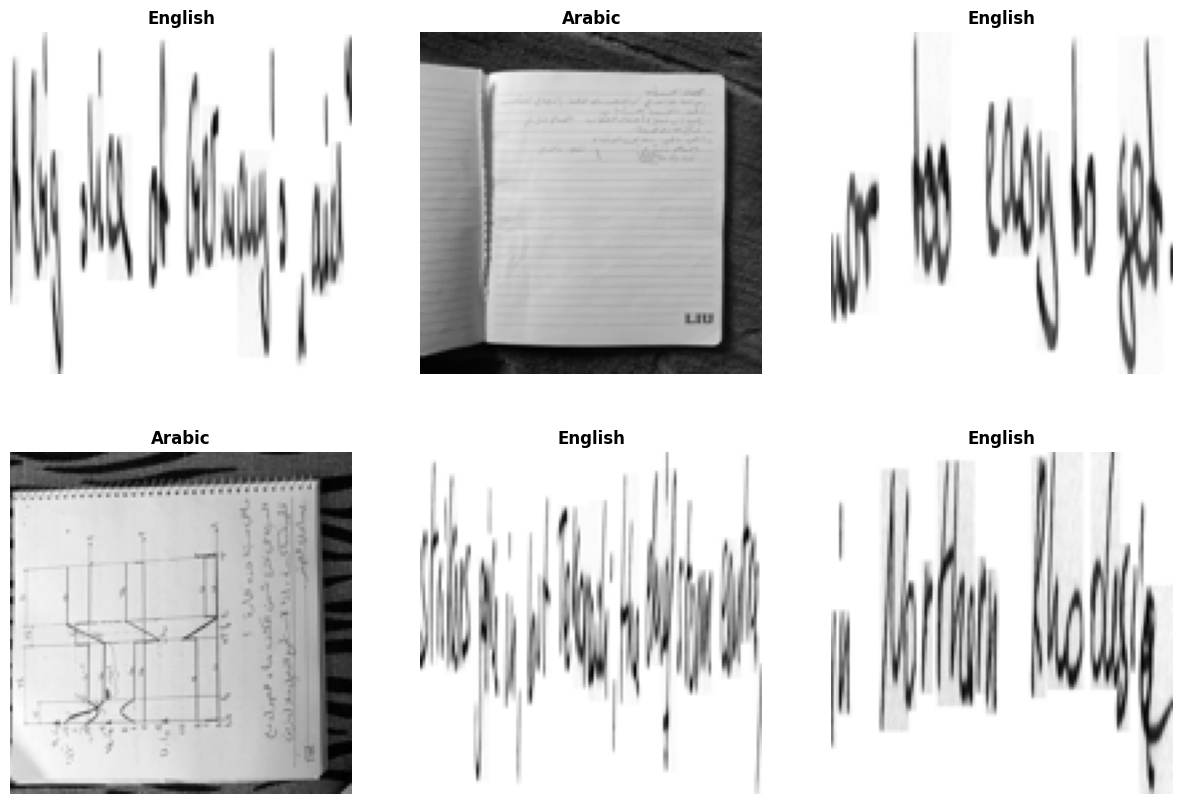

In [ ]:
def visualize_sample_images(df, num_samples=6, img_height=128, img_width=128):
    """
    Visualize multiple random images from the dataset.
    
    Parameters:
    - df: DataFrame with 'image' and 'language' columns
    - num_samples: Number of images to display
    - img_height: Height of the image
    - img_width: Width of the image
    """
    
    sample_df = df.sample(n=min(num_samples, len(df)), random_state=42)
    
    rows = (num_samples + 2) // 3 
    cols = min(3, num_samples)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    
    if num_samples == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if num_samples > 3 else axes
    
    for idx, (_, row) in enumerate(sample_df.iterrows()):
        if idx >= num_samples:
            break
            
        img_2d = row['image'].reshape(img_height, img_width)
        
        axes[idx].imshow(img_2d, cmap='gray')
        axes[idx].set_title(f"{row['language'].capitalize()}", fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    plt.show()

visualize_sample_images(df, num_samples=6, img_height=128, img_width=128)

In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ipythonx/msratd500")

print("Path to dataset files:", path)

100%|██████████| 96.2M/96.2M [00:03<00:00, 30.6MB/s]

Extracting files...


Path to dataset files: C:\Users\Liam\.cache\kagglehub\datasets\ipythonx\msratd500\versions\1
